# Day 4 · 决策树——用 if-else 做分类

> 目标：理解决策树怎么切数据，可视化树结构
> 决策树是唯一能**直接画出决策逻辑**的模型——你 C++ 数据结构里写的条件分支就是它的本质

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False
print("=─" * 20)
print("Day 4 · 决策树")
print("=─" * 20)

=─=─=─=─=─=─=─=─=─=─=─=─=─=─=─=─=─=─=─=─
Day 4 · 决策树
=─=─=─=─=─=─=─=─=─=─=─=─=─=─=─=─=─=─=─=─


## 1. 决策树的核心问题

> **用哪个特征切？切在哪？**

C++ 里你写：


决策树就是**自动找到**最佳的 (特征, 阈值) 组合，而不是你手动写。

In [5]:
data = load_breast_cancer()
X = data.data; y = data.target
feat_names = data.feature_names

print(f"样本: {X.shape[0]}, 特征: {X.shape[1]}")
print(f"良性: {(y==1).sum()}, 恶性: {(y==0).sum()}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"训练集: {len(X_train)}, 测试集: {len(X_test)}")

样本: 569, 特征: 30
良性: 357, 恶性: 212
训练集: 455, 测试集: 114


## 2. 用哪个特征切？—— 基尼系数

446Gini = 1 - \sum_{k=1}^{K} p_k^2446

- 全是同一类 → Gini=0（最纯）
- 各类各占一半 → Gini=0.5（最混）
- 决策树每次选**Gini 下降最多**的特征来切

In [13]:
def gini(y):
    """算一下基尼系数，理解纯度"""
    _, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return 1 - (probs ** 2).sum()

print(f"全良性 Gini: {gini(np.ones(100)):.3f}")
print(f"全恶性 Gini: {gini(np.zeros(100)):.3f}")
print(f"一半一半 Gini: {gini(np.array([0]*50+ [1]*50)):.3f}")
print(f"结论: Gini 越小 → 越纯 → 越不需要再切")

全良性 Gini: 0.000
全恶性 Gini: 0.000
一半一半 Gini: 0.500
结论: Gini 越小 → 越纯 → 越不需要再切


## 3. 过拟合 vs 欠拟合

max_depth 是决策树最重要的参数——控制了树的深度

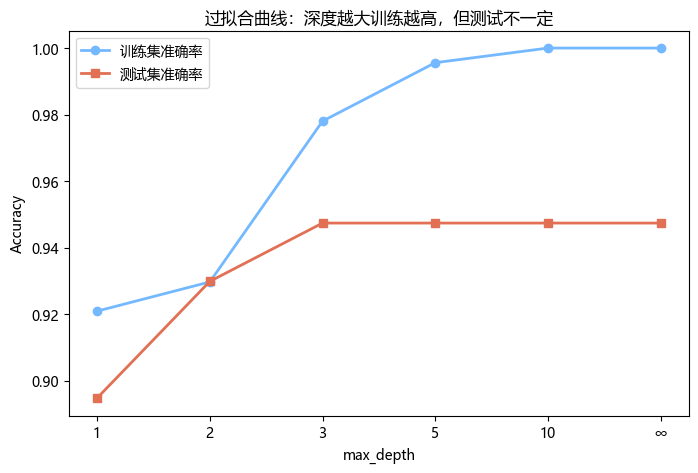

max_depth=  1: train=0.921, test=0.895
max_depth=  2: train=0.930, test=0.930
max_depth=  3: train=0.978, test=0.947
max_depth=  5: train=0.996, test=0.947
max_depth= 10: train=1.000, test=0.947
max_depth=  ∞: train=1.000, test=0.947
观察: depth=∞ 时训练=1.000 但测试反而下降 → 这就是过拟合


In [15]:
depths = [1, 2, 3, 5, 10, None]  # None = 不限制
train_scores, test_scores = [], []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_scores.append(tree.score(X_train, y_train))
    test_scores.append(tree.score(X_test, y_test))

# 画过拟合曲线
plt.figure(figsize=(8, 5))
labels = [str(d) if d else '∞' for d in depths]
plt.plot(labels, train_scores, 'o-', color='#74b9ff', linewidth=2, label='训练集准确率')
plt.plot(labels, test_scores, 's-', color='#e17055', linewidth=2, label='测试集准确率')
plt.xlabel('max_depth'); plt.ylabel('Accuracy'); plt.legend()
plt.title('过拟合曲线：深度越大训练越高，但测试不一定'); plt.show()

for d, tr, te in zip(labels, train_scores, test_scores):
    print(f"max_depth={d:>3}: train={tr:.3f}, test={te:.3f}")
print(f"观察: depth=∞ 时训练=1.000 但测试反而下降 → 这就是过拟合")

## 4. 可视化决策树（最重要！）

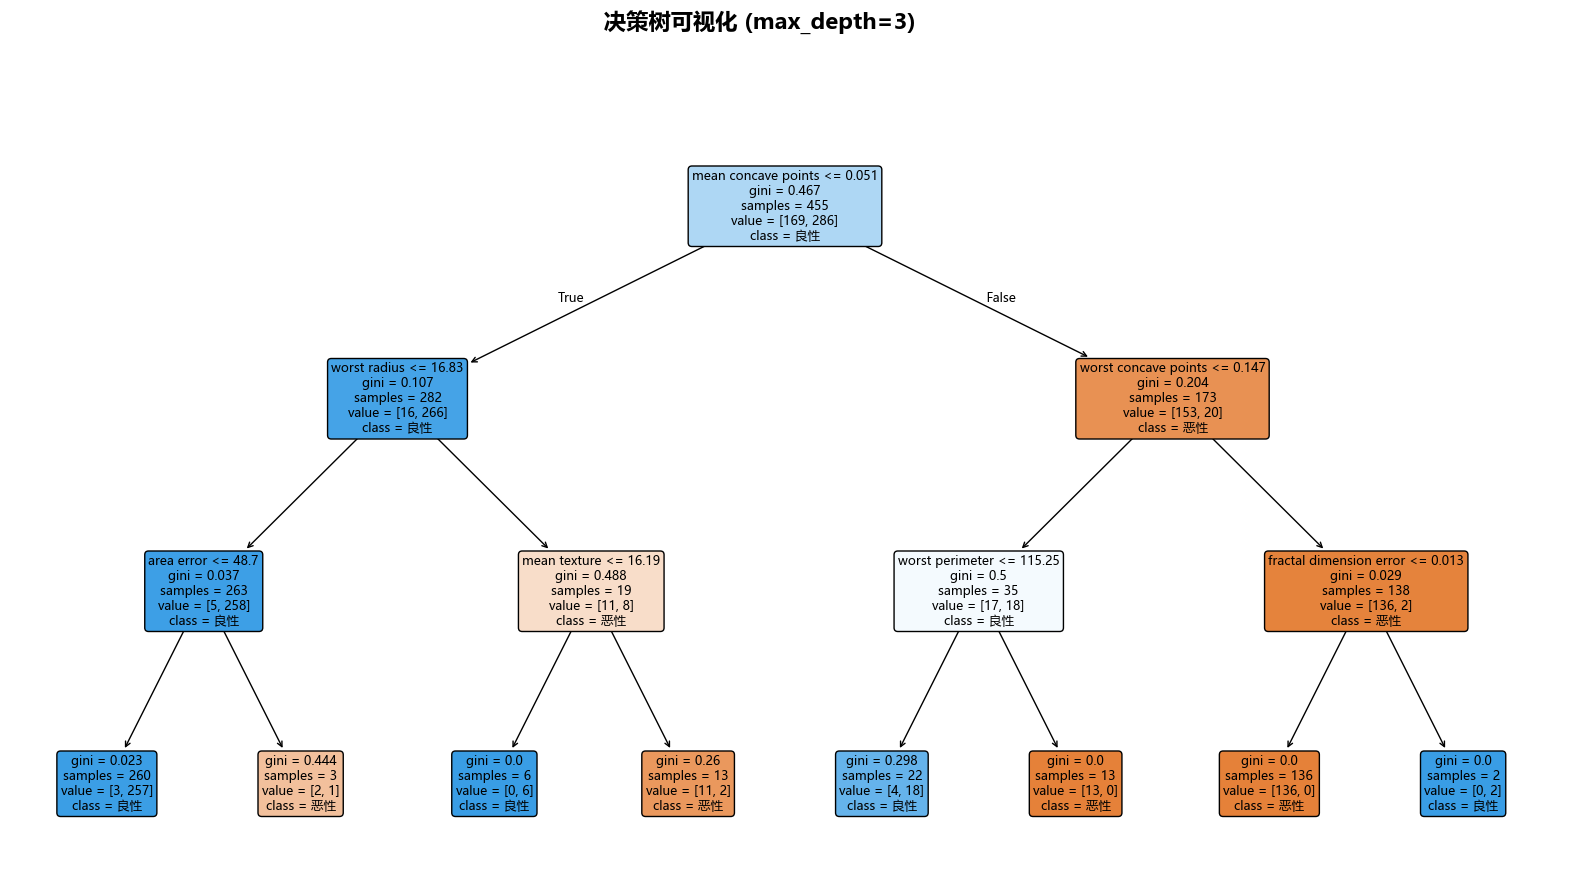

准确率: train=0.97802, test=0.94737


In [31]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(tree,
    feature_names=feat_names,
    class_names=['恶性', '良性'],
    filled=True, rounded=True,
    fontsize=9, impurity=True)
plt.suptitle('决策树可视化 (max_depth=3)', fontsize=16, fontweight='bold')
plt.savefig('day4_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'准确率: train={tree.score(X_train, y_train):.5f}, test={tree.score(X_test, y_test):.5f}')

## 5. 特征重要性——哪些特征最有用？

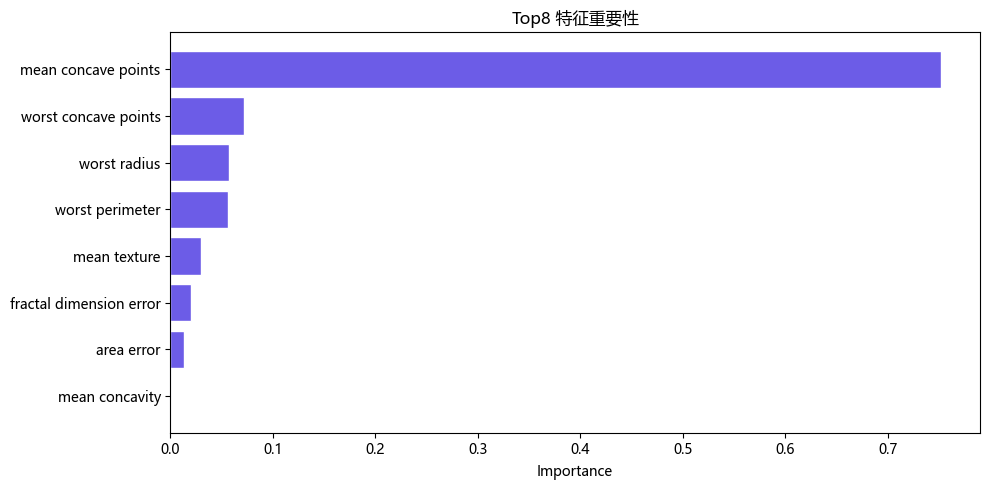

1. mean concave points            0.7523
2. worst concave points           0.0714
3. worst radius                   0.0569
4. worst perimeter                0.0560
5. mean texture                   0.0301
6. fractal dimension error        0.0202
7. area error                     0.0130
8. mean concavity                 0.0000


In [17]:
importances = tree.feature_importances_
indices = np.argsort(importances)[::-1][:8]  # 前8名

plt.figure(figsize=(10, 5))
plt.barh(range(8), importances[indices][::-1], color='#6c5ce7', edgecolor='white')
plt.yticks(range(8), [feat_names[i] for i in indices[::-1]])
plt.xlabel('Importance'); plt.title('Top8 特征重要性')
plt.tight_layout(); plt.show()

for i, idx in enumerate(indices):
    print(f"{i+1}. {feat_names[idx]:30} {importances[idx]:.4f}")

## 6. 回到那棵树——顺着走一遍

In [25]:
# 取一个样本，人工模拟一遍决策
# 1. 确保输入是二维数组 (1, n_features)
sample = X_test[0:1] 
y_true = y_test[0]
print(f"真实标签: {'良性' if y_true==1 else '恶性'}")

# 2. 获取路径
node_indicator = tree.decision_path(sample)
leaf_id = tree.apply(sample)[0]
pred = tree.predict(sample)[0]

print(f"预测标签: {'良性' if pred==1 else '恶性'}")
print(f"落在叶子节点 ID: {leaf_id}")

# 3. 解析路径
# 获取该样本经过的所有节点 ID
path = node_indicator.indices[node_indicator.indptr[0]:node_indicator.indptr[1]]

print("决策路径详情:")
for node_id in path:
    # 情况 A: 如果是叶子节点
    if leaf_id == node_id:
        samples_count = tree.tree_.n_node_samples[node_id]
        values = np.round(tree.tree_.value[node_id][0]).astype(int)
        print(f"  -> [叶子节点 {node_id}] 结束。包含样本数={samples_count}, 类别分布(恶,良)={values}")
    
    # 情况 B: 如果是中间节点 (非叶子)
    else:
        feature_idx = tree.tree_.feature[node_id]
        threshold = tree.tree_.threshold[node_id]
        
        # 防止遇到 -2 (sklearn内部标记，虽少见但存在)
        if feature_idx != -2: 
            feature_name = feat_names[feature_idx]
            val = sample[0, feature_idx] # 注意这里用 sample[0, ...] 取值
            direction = '<=' if val <= threshold else '>'
            
            print(f"  -> [节点 {node_id}] 判断: {feature_name} {direction} {threshold:.4f} ? (当前值={val:.4f})")

真实标签: 良性
预测标签: 良性
落在叶子节点 ID: 3
决策路径详情:
  -> [节点 0] 判断: mean concave points <= 0.0513 ? (当前值=0.0382)
  -> [节点 1] 判断: worst radius <= 16.8300 ? (当前值=14.9700)
  -> [节点 2] 判断: area error <= 48.7000 ? (当前值=30.2900)
  -> [叶子节点 3] 结束。包含样本数=260, 类别分布(恶,良)=[0 1]


# 🎉 Day 4 完成！

## 今天学到的

| 概念 | 一句话 |
|------|--------|
| **决策树** | 递归找最佳 (特征, 阈值) 来切数据 |
| **基尼系数** | 衡量纯度——越小越好 |
| **max_depth** | 树太深→记住训练数据的噪声→过拟合 |
| **特征重要性** | 哪些特征在决策中被用了最多 |

## C++ 角度



## 晚上作业

1. 顺着上面的树图，随便挑一个叶子节点，从根走一遍
2. 把 max_depth 从 3 改成 5，树大了多少？
3. 预习：100棵树一起投票 vs 1棵树 → 引出 Day5 随机森林
